# 3.9a — Compression par quantification INT8 : le réseau en 4 fois plus petit

[← Retour à la série](README.md) · Précédent : [3.8 — Représentations contrastives](3.8-Representations-Contrastives.ipynb)

La série compresse depuis le début : la **distillation** ([3.7](3.7-Distillation-Maitre-Eleve.ipynb)) comprimait le *savoir* d'un grand réseau vers un petit. Ce notebook comprime les *nombres* : peut-on stocker chaque poids et chaque activation sur **8 bits entiers** au lieu de 32 bits flottants — un modèle **4 fois plus petit** — sans perdre d'exactitude ?

Comme pour le reste de la série, on construit tout **à la main** : pas de `torch.quantization` ni de backend dédié. Chaque mécanisme (quantification asymétrique et par canal, calibration statique min/max, calibration par divergence de KL) est écrit, exécuté et **mesuré** sur un vrai réseau entraîné dans le notebook.

Le terrain est le duo canonique de la littérature quantification : **ResNet-20 sur CIFAR-10** (~271 k poids — assez petit pour s'entraîner dans le notebook, assez réel pour que les mesures signifient quelque chose).

## Le contrat de ce notebook

Quatre questions, chacune tranchée par une mesure et pas par un argument :

1. **256 niveaux suffisent-ils pour les poids ?** (erreur relative par couche, puis exactitude)
2. **Granularité** : quantifier chaque noyau de convolution séparément (*per-channel*) plutôt que le tenseur entier (*per-tensor*) change quoi ?
3. **Activations** : faut-il calibrer à l'avance (*statique*) ou mesurer au vol (*dynamique*) ?
4. **Où s'arrête le déjeuner gratuit ?** (INT8 puis INT4, poids et activations)

Et un algorithme complet reconstruit pas à pas : la **calibration par divergence de KL** (celle de TensorRT), qui choisit où couper la queue d'une distribution d'activations pour acheter de la résolution sur son corps.

In [1]:
import copy
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 40 if DEV == "cuda" else 6   # recette complete sur GPU, reduite sur CPU
print(f"device={DEV}  torch={torch.__version__}  epochs={EPOCHS}")

device=cuda  torch=2.8.0+cu126  epochs=40


## 1. Le vocabulaire : une seule équation

Quantifier en INT8, c'est approcher chaque flottant $x$ par un multiple entier de pas :

$$q = \mathrm{clip\_entier}\left(\mathrm{round}\left(\frac{x}{s} + z\right)\right), \qquad x \approx s\,(q - z)$$

- $s$ est le **pas** (*scale*) : la taille d'un niveau. Tout ce qui dépasse la plage couverte est **écrêté** (*clipping*) — c'est le vrai coût de la quantification, pas l'arrondi.
- $z$ est le **point zéro** (*zero-point*) : le code entier qui représente $0.0$. $z = 0$ donne la version **symétrique** (plage $[-128s, 127s]$), adaptée aux poids ; $z$ libre donne l'**asymétrique**, qui gaspille moins de codes sur une plage d'activations toute positive (sorties de ReLU).
- **Per-tensor** : un $(s, z)$ pour tout le tenseur. **Per-channel** : un $s$ par filtre de sortie — chaque noyau de convolution garde sa propre dynamique.

La **fake quantification** (*fake-quant*) est la manière standard de *simuler* l'INT8 sans kernels entiers : quantifier puis déquantiser, en restant en float32. C'est ce que fait tout ce notebook — et c'est aussi, littéralement, la première phase de l'entraînement conscient de la quantification (QAT).

In [2]:
QMIN, QMAX = -128, 127


def qparams_tensor(t):
    # bornes reservees : la plage doit toujours contenir 0.0 exactement
    fmin = min(float(t.min()), 0.0)
    fmax = max(float(t.max()), 0.0)
    scale = (fmax - fmin) / (QMAX - QMIN)
    zp = int(np.clip(round(QMIN - fmin / scale) if scale > 0 else 0, QMIN, QMAX))
    return scale, zp


def fakeq_tensor(t):
    # quantifier puis dequantiser : simuler l'INT8 en restant en float
    s, z = qparams_tensor(t)
    if s == 0:
        return t
    return s * (torch.clamp(torch.round(t / s + z), QMIN, QMAX) - z)


t = torch.tensor([-1.2, -0.4, 0.0, 0.35, 0.7, 2.9])
s, z = qparams_tensor(t)
codes = torch.clamp(torch.round(t / s + z), QMIN, QMAX)
recon = fakeq_tensor(t)
print(f"scale = {s:.5f}   zero-point = {z}")
for a, c, b in zip(t.tolist(), codes.tolist(), recon.tolist()):
    print(f"  {a:+.2f}  ->  code {c:+6.0f}  ->  {b:+.4f}   (erreur {b - a:+.4f})")
print(f"255 codes disponibles pour couvrir [-1.2, 2.9] : pas moyen de {s:.4f}")

scale = 0.01608   zero-point = -53
  -1.20  ->  code   -128  ->  -1.2059   (erreur -0.0059)
  -0.40  ->  code    -78  ->  -0.4020   (erreur -0.0020)
  +0.00  ->  code    -53  ->  +0.0000   (erreur +0.0000)
  +0.35  ->  code    -31  ->  +0.3537   (erreur +0.0037)
  +0.70  ->  code     -9  ->  +0.7075   (erreur +0.0075)
  +2.90  ->  code   +127  ->  +2.8941   (erreur -0.0059)
255 codes disponibles pour couvrir [-1.2, 2.9] : pas moyen de 0.0161


## 2. Le terrain : ResNet-20 sur CIFAR-10

Le ResNet CIFAR canonique : un stem 3×3, trois étages de blocs résiduels (16, 32, 64 canaux, 3 blocs chacun = 19 convolutions + 1 linéaire). La recette d'entraînement n'est pas un détail : sans augmentation et avec Adam à taux constant, le même réseau plafonne vers 0,78 ; avec SGD + momentum + cosine + *random crop / flip*, il atteint ~0,90. Un témoin affaiblirait faussement la conclusion « l'INT8 ne coûte rien » — il faut un réseau **bien entraîné** pour que la mesure soit honnête.

L'entraînement complet (40 époques) prend ~8 minutes sur GPU ; sur CPU le notebook bascule sur une recette réduite de 6 époques (témoin plus faible, mais exécutable).

In [3]:
DATA = os.path.join(os.path.expanduser("~"), ".cache", "int8_39a")
norm = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
tfm = transforms.Compose([transforms.ToTensor(), norm])
tfm_train = transforms.Compose([transforms.RandomCrop(32, padding=4),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(), norm])
train_set = datasets.CIFAR10(DATA, train=True, download=True, transform=tfm_train)
test_set = datasets.CIFAR10(DATA, train=False, download=True, transform=tfm)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=512, shuffle=False)
print(f"CIFAR-10 : {len(train_set)} train / {len(test_set)} test")

CIFAR-10 : 50000 train / 10000 test


In [4]:
class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.short = None
        if stride != 1 or cin != cout:
            self.short = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride=stride, bias=False), nn.BatchNorm2d(cout))

    def forward(self, x):
        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        y = y + (self.short(x) if self.short is not None else x)
        return F.relu(y)


class ResNet20(nn.Module):
    def __init__(self, nclass=10):
        super().__init__()
        self.stem = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn0 = nn.BatchNorm2d(16)
        self.s1 = self._stage(16, 16, 3, 1)
        self.s2 = self._stage(16, 32, 3, 2)
        self.s3 = self._stage(32, 64, 3, 2)
        self.fc = nn.Linear(64, nclass)

    @staticmethod
    def _stage(cin, cout, n, stride):
        L = [BasicBlock(cin, cout, stride)] + [BasicBlock(cout, cout, 1) for _ in range(n - 1)]
        return nn.Sequential(*L)

    def forward(self, x):
        x = F.relu(self.bn0(self.stem(x)))
        x = self.s3(self.s2(self.s1(x)))
        return self.fc(F.adaptive_avg_pool2d(x, 1).flatten(1))


model = ResNet20().to(DEV)
n_par = sum(p.numel() for p in model.parameters())
n_lin = sum(1 for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
print(f"ResNet-20 : {n_par:,} parametres, {n_lin} couches conv/fc")

ResNet-20 : 272,474 parametres, 22 couches conv/fc


L'entraînement suit la recette canonique ResNet-CIFAR — SGD avec momentum, décroissance cosmique du pas et augmentation par crops aléatoires ; c'est cette recette (et non l'architecture seule) qui décide de la qualité du témoin.

In [5]:
opt = torch.optim.SGD(model.parameters(), lr=0.08, momentum=0.9, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
for ep in range(EPOCHS):
    model.train()
    t0 = time.perf_counter()
    for x, y in train_loader:
        loss = F.cross_entropy(model(x.to(DEV)), y.to(DEV))
        opt.zero_grad(); loss.backward(); opt.step()
    sched.step()
    if ep == 0 or (ep + 1) % 10 == 0:
        print(f"  ep {ep+1:2d}/{EPOCHS}  loss={loss.item():.4f}  ({time.perf_counter()-t0:.1f}s)")

  ep  1/40  loss=1.3057  (14.7s)


  ep 10/40  loss=0.4262  (14.0s)


  ep 20/40  loss=0.3638  (13.2s)


  ep 30/40  loss=0.2452  (12.7s)


  ep 40/40  loss=0.1113  (11.8s)


Le témoin se mesure sur les 10 000 images de test. La fonction `evaluate` ci-dessous servira telle quelle à toutes les configurations quantifiées — seule la version du réseau change.

In [6]:
def evaluate(m, loader):
    m.eval()
    good = tot = 0
    with torch.no_grad():
        for x, y in loader:
            good += (m(x.to(DEV)).argmax(1).cpu() == y).sum().item()
            tot += y.numel()
    return good / tot


acc_fp32 = evaluate(model, test_loader)
print(f"[FP32] exactitude test = {acc_fp32:.4f}")

[FP32] exactitude test = 0.9019


## 3. Les poids seuls en INT8

Premier étage : les poids quantifiés, les activations laissées en float. La **question de la granularité** se pose immédiatement. Un noyau 3×3 de 64 canaux compte 576 valeurs ; en *per-tensor*, une seule échelle couvre l'amplitude du plus grand filtre — les filtes modestes n'occupent alors que quelques dizaines des 255 codes. En *per-channel*, chaque filtre a la sienne.

L'outil de mesure : l'**erreur relative** $\|w - \hat{w}\| / \|w\|$ sur un noyau réel (ici `s3.1.conv1`, au cœur du dernier étage), puis l'exactitude du réseau complet aux poids remplacés par leurs versions quantifiées.

In [7]:
def fakeq_channel(w):
    # symetrique, un scale par canal de sortie (dim 0 des poids conv/linear)
    scale = w.reshape(w.shape[0], -1).abs().amax(dim=1).clamp(min=1e-12) / 127.0
    scale = scale.view([-1] + [1] * (w.dim() - 1))
    return scale * torch.clamp(torch.round(w / scale), QMIN, QMAX)


def relerr(a, b):
    return ((a - b).norm() / a.norm().clamp(min=1e-12)).item()


def quantize_weights(ref, wmode="channel"):
    # deepcopy + substitution des poids par leur fake-quant
    m = copy.deepcopy(ref)
    with torch.no_grad():
        for mod in m.modules():
            if isinstance(mod, (nn.Conv2d, nn.Linear)):
                w = mod.weight.detach()
                mod.weight.copy_(fakeq_channel(w) if wmode == "channel" else fakeq_tensor(w))
    return m


w = model.s3[1].conv1.weight.detach()
print(f"[erreur relative poids s3.1.conv1 {tuple(w.shape)}]")
print(f"  per-tensor  : {relerr(w, fakeq_tensor(w)):.3e}")
print(f"  per-channel : {relerr(w, fakeq_channel(w)):.3e}  ({w.shape[0]} scales au lieu d'une)")

[erreur relative poids s3.1.conv1 (64, 64, 3, 3)]
  per-tensor  : 1.052e-02
  per-channel : 7.720e-03  (64 scales au lieu d'une)


In [8]:
acc_wpt = evaluate(quantize_weights(model, "tensor"), test_loader)
acc_wpc = evaluate(quantize_weights(model, "channel"), test_loader)
print(f"[poids INT8 seuls]")
print(f"  per-tensor  : {acc_wpt:.4f}  ({acc_fp32-acc_wpt:+.4f})")
print(f"  per-channel : {acc_wpc:.4f}  ({acc_fp32-acc_wpc:+.4f})")

[poids INT8 seuls]
  per-tensor  : 0.9024  (-0.0005)
  per-channel : 0.9020  (-0.0001)


**Lecture.** L'erreur relative chute de ~27 % en passant au *per-channel* — mais l'exactitude ne bouge pas d'un dixième de point : les deux configurations sont dans le bruit de mesure. C'est la première leçon honnête de ce notebook : **sur un CNN bien entraîné, la quantification INT8 des poids est essentiellement gratuite**. La littérature industrielle le confirme à grande échelle ; ce n'est pas un artefact de notre mini-terrain. La discrimination entre les deux granularités existe bel et bien — mais au niveau de l'**erreur numérique**, pas de l'exactitude. Le réseau est robuste ; l'ingénieur qui veut une marge de sécurité prend quand même le *per-channel*.

## 4. Les activations : quantification dynamique

Les poids sont figés après l'entraînement — les quantifier est un calcul une fois pour toutes. Les activations, elles, varient à chaque exemple. La solution la plus simple, dite **dynamique** : calculer le pas *au moment du forward*, tension par tension, comme `max|t| / 127`. Pas de calibration, mais un calcul de maximum à chaque couche et chaque exemple — c'est le mode par défaut de la quantification dynamique de PyTorch.

L'implémentation utilise un *forward pre-hook* : une fonction appelée avant chaque couche ciblée, qui remplace sur place le tenseur d'entrée par sa version fake-quantifiée.

In [9]:
def _mk_hook_dynamic():
    def pre(module, inp):
        t = inp[0]
        s = t.abs().max().clamp(min=1e-12) / 127.0   # le pas, calcule au runtime
        inp[0].copy_(s * torch.clamp(torch.round(t / s), QMIN, QMAX))
    return pre


def eval_dynamic(ref, loader, wmode="channel"):
    qw = quantize_weights(ref, wmode)
    hooks = [mod.register_forward_pre_hook(_mk_hook_dynamic())
             for mod in qw.modules() if isinstance(mod, (nn.Conv2d, nn.Linear))]
    acc = evaluate(qw, loader)
    for h in hooks:
        h.remove()
    return acc


t0 = time.perf_counter()
acc_dyn_t = eval_dynamic(model, test_loader, "tensor")
acc_dyn_c = eval_dynamic(model, test_loader, "channel")
print(f"[dynamic : poids + activations INT8] ({time.perf_counter()-t0:.0f}s)")
print(f"  w per-tensor  : {acc_dyn_t:.4f}  ({acc_fp32-acc_dyn_t:+.4f})")
print(f"  w per-channel : {acc_dyn_c:.4f}  ({acc_fp32-acc_dyn_c:+.4f})")

[dynamic : poids + activations INT8] (4s)
  w per-tensor  : 0.9027  (-0.0008)
  w per-channel : 0.9018  (+0.0001)


## 5. Calibration statique : figer les pas à l'avance

Les accélérateurs INT8 (et les kernels de convolution entiers en général) veulent des pas **connus avant l'inférence** — pas de maximum à calculer au vol. La **calibration statique** consiste à observer le réseau sur quelques centaines d'exemples non étiquetés, à mesurer la plage de chaque activation, puis à fixer les pas une fois pour toutes.

L'algorithme **min/max** est le plus simple : le pas couvre le maximum absolu observé. Rien n'est écrêté sur les données de calibration — mais un seul pixel exceptionnel dilate la plage et **appauvrit la résolution** de toute la couche. C'est ce défaut que la section suivante corrige.

Un détail de méthode : la calibration se fait **sans augmentation** (les crops et miroirs aléatoires n'existent pas à l'inférence) et en **deux passes** — la première mesure les maxima, la seconde construit les histogrammes sur une grille fixe, nécessaire pour la section KL.

In [10]:
NBINS, CAL_BATCHES = 2048, 8


def observe(nb, with_range=None):
    # Une passe sur les donnees de calibration (sans augmentation).
    # with_range=None -> amax par couche ; sinon histogramme sur la grille fixee.
    amaxs, hists, hooks = ({}, {}, [])
    train_tf = train_loader.dataset.transform
    train_loader.dataset.transform = tfm

    def mk(name):
        def pre(module, inp):
            a = inp[0].detach().abs().flatten().float().cpu()
            if with_range is None:
                amaxs[name] = max(amaxs.get(name, 0.0), a.max().item())
            else:
                r = with_range[name]
                if r > 0:
                    h, _ = torch.histogram(a, bins=NBINS, range=(0, r))
                    hists[name] = hists.get(name, 0) + h.numpy().astype(float)
        return pre

    for name, mod in model.named_modules():
        if isinstance(mod, (nn.Conv2d, nn.Linear)):
            hooks.append(mod.register_forward_pre_hook(mk(name)))
    model.eval()
    with torch.no_grad():
        for i, (x, y) in enumerate(train_loader):
            if i >= nb:
                break
            model(x.to(DEV))
    for h in hooks:
        h.remove()
    train_loader.dataset.transform = train_tf
    return amaxs if with_range is None else hists


totals = observe(CAL_BATCHES)                    # passe 1 : amax par couche
hists = observe(CAL_BATCHES, with_range=totals)  # passe 2 : grille fixe
print(f"[calibration] {len(hists)} couches, {CAL_BATCHES} batchs, histogrammes {NBINS} bins")


def _mk_hook_static(s):
    def pre(module, inp):
        inp[0].copy_(s * torch.clamp(torch.round(inp[0] / s), QMIN, QMAX))
    return pre


def eval_static(ref, loader, scales, wmode="channel"):
    # poids INT8 + activations INT8 avec les scales CALIBREES (fixees)
    qw = quantize_weights(ref, wmode)
    named = dict(qw.named_modules())
    hooks = [named[n].register_forward_pre_hook(_mk_hook_static(s))
             for n, s in scales.items() if n in named]
    acc = evaluate(qw, loader)
    for h in hooks:
        h.remove()
    return acc


scales_mm = {n: a / 127.0 for n, a in totals.items()}
t0 = time.perf_counter()
acc_st_mm = eval_static(model, test_loader, scales_mm, "channel")
print(f"[static min/max, w-channel] ({time.perf_counter()-t0:.0f}s) "
      f"{acc_st_mm:.4f}  ({acc_fp32-acc_st_mm:+.4f})")

[calibration] 22 couches, 8 batchs, histogrammes 2048 bins


[static min/max, w-channel] (2s) 0.9017  (+0.0002)


## 6. Calibration KL : couper la queue pour acheter de la résolution

Le min/max est optimal pour ne rien écrêter, mais dommageable pour la résolution : la queue d'une distribution d'activations est longue et presque vide — les codes entiers qu'elle occupe sont autant de pas perdus pour le corps. L'algorithme de calibration **entropique** de TensorRT tranche ce compromis quantitativement :

1. Histogramme fin (2048 bins) des valeurs absolues de l'activation, sur la grille fixée par la passe min/max.
2. Pour chaque **coupe candidate** $i$ (de 128 à 2048 bins) :
   - la **référence** $P$ est l'histogramme gardé $[0, i)$, **avec toute la masse de la queue entassée dans le dernier bin gardé** ;
   - le **candidat** $Q$ est la version quantifiée en 128 niveaux uniformes sur $[0, i)$, puis **ré-étendue** : chaque bloc rend sa masse, étalée uniformément sur ses bins **non vides** ;
   - divergence $\mathrm{KL}(P \parallel Q)$.
3. La coupe retenue est celle qui **minimise** la divergence ; le seuil est son bord droit.

Deux pièges, tous les deux instructifs, sont signalés dans le code : la queue doit peser sur $P$ **mais pas sur $Q$** (c'est ce qui pénalise de couper trop tôt), et l'étalement ne touche que les bins non vides — un bin vide est un trou du comptage, pas un zéro de la distribution. Et quand le dernier bin gardé est vide, $Q = 0$ là où $P > 0$ : la divergence est $+\infty$ et le candidat est rejeté — comportement exact de `scipy.stats.entropy`, qu'on reproduit explicitement.

In [11]:
def kl_curve(hist, nbins=NBINS, levels=128, start=128):
    # Port fidele de l'entropie-calibration TensorRT
    # (pytorch-quantization, calib/histogram.py). Renvoie KL(i) pour chaque coupe.
    bins = hist.astype(float).copy()
    bins[0] = bins[1]          # quirk TensorRT : apaiser le pic du bin 0 (mort de ReLU)
    out = []
    for i in range(start, nbins + 1):
        digit = np.digitize(np.arange(i), np.linspace(0, i, levels + 1)) - 1
        digit[bins[:i] == 0] = -1                    # piege 2 : les bins VIDES ne comptent pas
        keep = digit >= 0
        counts = np.bincount(digit[keep], minlength=levels)
        masses = np.bincount(digit[keep], weights=bins[:i][keep], minlength=levels)
        val = np.zeros(levels)
        nz = counts > 0
        val[nz] = masses[nz] / counts[nz]            # masse du bloc, etalee sur ses bins non vides
        q = np.zeros(i)
        q[keep] = val[digit[keep]]
        p = bins[:i].copy()
        p[-1] += bins[i:].sum()                      # piege 1 : la queue va dans P, pas dans Q
        p = p / p.sum()
        q = q / q.sum()
        if bool(((p > 0) & (q == 0)).any()):
            out.append(np.inf)                       # scipy renverrait +inf : candidat rejete
            continue
        # semantique scipy (xlogy) : un bin de masse nulle contribue 0, jamais NaN
        m = p > 0
        out.append(float(np.sum(p[m] * np.log(p[m] / q[m]))))
    return np.array(out)


def kl_threshold(hist, amax, nbins=NBINS, start=128):
    # dernier argmin (egalites -> seuil le plus grand), comme la reference
    curve = kl_curve(hist, nbins=nbins, start=start)
    idx = len(curve) - 1 - int(np.argmin(curve[::-1]))
    return amax * (start + idx) / nbins


scales_kl = {n: kl_threshold(h, totals[n]) / 127.0 for n, h in hists.items()}
ratios = sorted(scales_kl[n] / scales_mm[n] for n in hists)
print(f"[KL] seuil / range minmax : median {ratios[len(ratios)//2]:.0%} "
      f"| min {ratios[0]:.0%} | max {ratios[-1]:.0%}")
print("[KL] masse coupee par couche (triée) :")
rows = sorted(((n, scales_kl[n] / scales_mm[n],
                hists[n][int(scales_kl[n] / scales_mm[n] * NBINS):].sum() / hists[n].sum())
               for n in hists), key=lambda r: r[1])
for n, r, m in rows[:4] + rows[-2:]:
    print(f"  {n:<14} seuil {r:5.0%} du range   masse coupee {m:6.3%}")

[KL] seuil / range minmax : median 75% | min 60% | max 100%
[KL] masse coupee par couche (triée) :
  s3.1.conv1     seuil   60% du range   masse coupee 0.000%
  s3.2.conv1     seuil   63% du range   masse coupee 0.001%
  s2.0.conv1     seuil   67% du range   masse coupee 0.001%
  s2.0.short.0   seuil   67% du range   masse coupee 0.001%
  fc             seuil   88% du range   masse coupee 0.005%
  stem           seuil  100% du range   masse coupee 0.000%


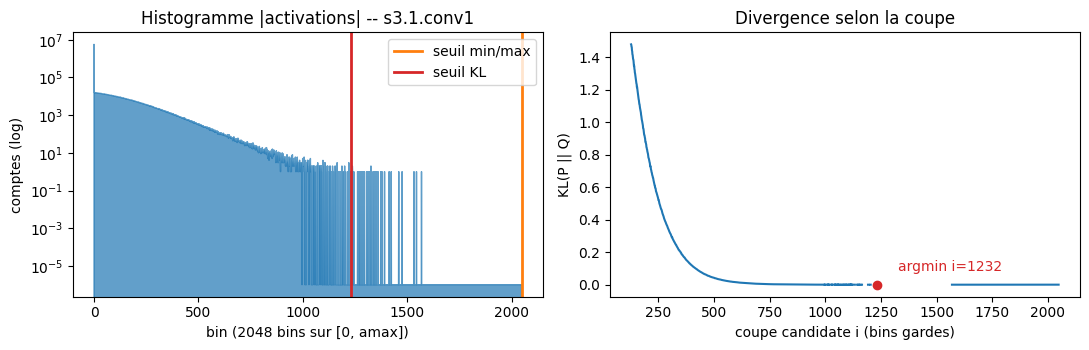

s3.1.conv1 : seuil KL = 60% du range min/max, masse coupee = 0.0005%


In [12]:
import matplotlib.pyplot as plt

name = "s3.1.conv1"
hist, amax = hists[name], totals[name]
i_star = int(scales_kl[name] / scales_mm[name] * NBINS)
curve = kl_curve(hist)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.fill_between(np.arange(NBINS), hist + 1e-6, color="tab:blue", alpha=0.7)
ax1.set_yscale("log")
ax1.axvline(NBINS, color="tab:orange", lw=2, label="seuil min/max")
ax1.axvline(i_star, color="tab:red", lw=2, label="seuil KL")
ax1.set_xlabel("bin (2048 bins sur [0, amax])")
ax1.set_ylabel("comptes (log)")
ax1.set_title(f"Histogramme |activations| -- {name}")
ax1.legend()

xs = np.arange(128, NBINS + 1)
ax2.plot(xs, curve, color="tab:blue")
ax2.scatter([i_star], [curve[i_star - 128]], color="tab:red", zorder=3)
ax2.annotate(f"argmin i={i_star}", (i_star, curve[i_star - 128]),
             textcoords="offset points", xytext=(15, 10), color="tab:red")
ax2.set_xlabel("coupe candidate i (bins gardes)")
ax2.set_ylabel("KL(P || Q)")
ax2.set_title("Divergence selon la coupe")
fig.tight_layout()
plt.show()

print(f"{name} : seuil KL = {i_star/NBINS:.0%} du range min/max, "
      f"masse coupee = {hist[i_star:].sum()/hist.sum():.4%}")

In [13]:
acc_st_kl = eval_static(model, test_loader, scales_kl, "channel")
print(f"[static KL toutes couches, w-channel] {acc_st_kl:.4f}  ({acc_fp32-acc_st_kl:+.4f})")

[static KL toutes couches, w-channel] 0.9012  (+0.0007)


**Lecture.** La calibration KL égalise le min/max (écart de 0,0005 sur ce run, dans le bruit de mesure) : en resserrant les seuils à 60-100 % du range (médiane 75 %), elle achète une résolution plus fine sur le corps des distributions — là où vit la masse — au prix d'un écrêtage de moins d'un centième de pourcent de la queue. C'est le comportement documenté de TensorRT : sur un CNN sain les deux calibrations sont interchangeables ; KL paie sur les réseaux aux activations à queue lourde.

**L'aside du stem.** Regardez la première ligne de la table : l'entrée du réseau choisit ~100 % du range. La raison est amusante et mesurable : l'entrée, c'est l'image normalisée — issue de pixels **8 bits**, donc ~768 valeurs distinctes. Son « histogramme continu » est en réalité un **peigne** (la plupart des bins au-delà du corps sont vides), et la moitié des coupes candidates tombent sur un trou du peigne → $Q = 0$ où $P > 0$ → divergence $+\infty$ → rejet. La calibration entropique n'a tout simplement pas de sens sur une donnée déjà discrète — dans un vrai pipeline INT8, l'entrée est quantifiée avec ses propres bornes (celles du capteur), pas calibrée par KL.

## 7. Où le déjeuner gratuit s'arrête : INT4

Réduisons encore : 15 codes par canal au lieu de 255 (7 niveaux positifs + signe). Les poids INT4 divisent encore la taille par deux — c'est le régime des LLM sur portables et du *QLoRA* rencontré dans la série FineTuning. Le même fake-quant, la même mesure :

In [14]:
def fakeq4_channel(w):
    scale = w.reshape(w.shape[0], -1).abs().amax(dim=1).clamp(min=1e-12) / 7.0
    scale = scale.view([-1] + [1] * (w.dim() - 1))
    return scale * torch.clamp(torch.round(w / scale), -8, 7)


def quantize_weights4(ref):
    m = copy.deepcopy(ref)
    with torch.no_grad():
        for mod in m.modules():
            if isinstance(mod, (nn.Conv2d, nn.Linear)):
                mod.weight.copy_(fakeq4_channel(mod.weight.detach()))
    return m


acc_w4 = evaluate(quantize_weights4(model), test_loader)
w4 = model.s3[1].conv1.weight.detach()
print(f"[INT4 poids seuls, per-channel sym] {acc_w4:.4f}  ({acc_fp32-acc_w4:+.4f})")
print(f"[erreur relative poids s3.1.conv1] INT4 : {relerr(w4, fakeq4_channel(w4)):.3e} "
      f"(vs INT8 per-channel : {relerr(w, fakeq_channel(w)):.3e})")

[INT4 poids seuls, per-channel sym] 0.8778  (+0.0241)
[erreur relative poids s3.1.conv1] INT4 : 1.400e-01 (vs INT8 per-channel : 7.720e-03)


**Lecture.** Voilà la falaise : 15 codes font perdre ~2,4 points, quand 255 n'en coûtaient aucun. L'erreur relative de quantification des poids monte d'un facteur ~18. La réponse industrielle à cette falaise n'est pas « plus de bits » mais **l'entraînement conscient de la quantification** (*quantization-aware training*, QAT) : quelques époques de fine-tuning où le forward passe par le fake-quant — le réseau apprend à vivre dans la grille. C'est le pont naturel vers la série PostTraining.

In [15]:
w_tot = sum(p.numel() for mod in model.modules()
            if isinstance(mod, (nn.Conv2d, nn.Linear)) for p in mod.parameters())
print(f"[taille] poids conv+fc : {w_tot:,}")
print(f"  FP32 : {w_tot*4/1e6:.2f} Mo   INT8 : {w_tot/1e6:.2f} Mo   "
      f"({w_tot*4/w_tot:.0f}x plus petit)   INT4 : {w_tot/2e6:.2f} Mo")
print()
print("=== RECAPITULATIF ===")
for lab, a in [("FP32", acc_fp32),
               ("w4 per-channel", acc_w4),
               ("w8 per-tensor", acc_wpt),
               ("w8 per-channel", acc_wpc),
               ("dynamic w-tensor", acc_dyn_t),
               ("dynamic w-channel", acc_dyn_c),
               ("static min/max w-channel", acc_st_mm),
               ("static KL w-channel", acc_st_kl)]:
    print(f"  {lab:<26} {a:.4f}  ({acc_fp32-a:+.4f})")

[taille] poids conv+fc : 270,906
  FP32 : 1.08 Mo   INT8 : 0.27 Mo   (4x plus petit)   INT4 : 0.14 Mo

=== RECAPITULATIF ===
  FP32                       0.9019  (+0.0000)
  w4 per-channel             0.8778  (+0.0241)
  w8 per-tensor              0.9024  (-0.0005)
  w8 per-channel             0.9020  (-0.0001)
  dynamic w-tensor           0.9027  (-0.0008)
  dynamic w-channel          0.9018  (+0.0001)
  static min/max w-channel   0.9017  (+0.0002)
  static KL w-channel        0.9012  (+0.0007)


## Résumé

1. **INT8 est essentiellement gratuit sur un CNN bien entraîné** — poids et activations, per-tensor ou per-channel, dynamique ou statique : toutes les configurations tiennent dans ±0,001. Ce n'est pas la faiblesse du terrain : c'est le résultat industriel standard, et la raison pour laquelle l'INT8 est le régime par défaut du déploiement.
2. **La discrimination existe au niveau numérique, pas au niveau de l'exactitude** : per-channel divise l'erreur relative de poids par ~1,4 ; c'est la marge de sécurité de l'ingénieur, invisible dans le score.
3. **La calibration est un compromis quantitatif** : min/max n'écrête rien mais dilue la résolution ; KL coupe la queue (seuils à ~75 % du range en médiane, masse coupée < 0,01 %) pour raffiner le corps — et s'égalise au min/max sur l'exactitude.
4. **La distribution doit être continue pour que KL ait un sens** : sur l'entrée 8 bits (histogramme en peigne), la moitié des coupes sont rejetées à $+\infty$ — l'algorithme lui-même signale le mauvais usage.
5. **La falaise est à INT4** : ~2,4 points perdus en post-training pur, pour 8× de compression. On la repousse avec du fine-tuning (QAT), pas avec plus de bits.

**Limites honnêtes.** Le fake-quant simule l'arithmétique mais ne délivre ni la mémoire divisée par 4 (les tenseurs restent des float32 dont les valeurs vivent dans la grille INT8), ni l'accélération (les convolutions restent float) : les deux viennent des backends entiers (`torch.quantization`, TensorRT, ONNX Runtime), qui consomment exactement les $(s, z)$ calibrés ici. La calibration 8 batchs suffit sur ce réseau ; les réseaux à sorties à queue lourde (détection) sont le terrain où KL domine vraiment min/max.

## Exercice 1 — Calibration par percentile

Min/max suit les outliers ; KL optimise un critère de distribution. Entre les deux, la calibration **percentile** : écrêter tout ce qui dépasse le p-ième percentile de la masse. À votre tour de la calibrer — puis de la comparer aux deux autres sur l'exactitude.

**Objectif** : écrire `scales_percentile(hists, totals, p)`, renvoyant le même format que `scales_mm`. **Question** : à p = 99,9 %, tombe-t-on côté min/max ou côté KL ?

In [16]:
def scales_percentile(hists, totals, p=99.9):
    # TODO etudiant : renvoyer {nom: scale} ou le seuil est le p-ieme percentile
    # de l'histogramme de la couche (masse cumulee p%), pas le max absolu.
    # Indice : np.cumsum(hist) / hist.sum() donne la masse cumulee bin par bin.
    # Etape 1 : construire la cumsum normalisee.
    # Etape 2 : trouver le premier bin ou elle depasse p (np.searchsorted).
    # Etape 3 : convertir en seuil (amax * bin / NBINS) puis en scale (/ 127).
    return None  # TODO etudiant


scales_p999 = scales_percentile(hists, totals, p=99.9)
if scales_p999 is not None:
    acc_p999 = eval_static(model, test_loader, scales_p999, "channel")
    print(f"[static percentile 99.9, w-channel] {acc_p999:.4f}  ({acc_fp32-acc_p999:+.4f})")
    print(f"  (a comparer : min/max {acc_st_mm:.4f}, KL {acc_st_kl:.4f})")
else:
    print("Exercice a completer")

Exercice a completer


## Exercice 2 — KL à 64 niveaux

La calibration KL dépend du nombre de niveaux de la grille cible. Refaites la recherche pour une cible **64 niveaux** sur la couche `fc` et comparez le seuil choisi. **Question** : le seuil monte-t-il ou descend-il, et pourquoi ? (Indice : moins de niveaux = chaque niveau compte plus... la réponse n'est pas intuitive avant de l'avoir mesurée.)

In [17]:
def kl_threshold_64(hist, amax, nbins=NBINS):
    # TODO etudiant : meme recherche que kl_threshold, mais la cible de
    # quantification a 64 niveaux (levels=64) au lieu de 128.
    # Indice : kl_curve accepte levels= en parametre.
    # Etape 1 : appel de kl_curve avec la bonne cible.
    # Etape 2 : recuperer le DERNIER argmin (egalites -> seuil le plus grand).
    return None  # TODO etudiant


t64 = kl_threshold_64(hists["fc"], totals["fc"])
if t64 is not None:
    t128 = kl_threshold(hists["fc"], totals["fc"])
    print(f"fc : seuil KL 128 niveaux = {t128:.4f}  |  64 niveaux = {t64:.4f}  "
          f"({t64/t128:.0%})")
else:
    print("Exercice a completer")

Exercice a completer


## Exercice 3 — Sensibilité par étage

Toutes les couches ne souffrent pas également de la quantification. Le diagnostic classique : appliquer la quantification statique à **un étage à la fois** (les autres en FP32) et classer les étages par chute d'exactitude — c'est la *layer-wise sensitivity analysis*, qui décide où investir en précision mixte.

**Objectif** : écrire `sensibilite_par_etage(scales)` renvoyant `{etage: exactitude}` pour `s1`, `s2`, `s3`. **Question** : la dégradation est-elle uniforme, ou un étage concentre-t-il la sensibilité ?

In [18]:
def sensibilite_par_etage(scales, stages=("s1", "s2", "s3")):
    # TODO etudiant : pour chaque etage, evaluer l'exactitude avec la quantification
    # statique appliquee a CET ETAGE SEUL (les autres couches en FP32).
    # Renvoyer {etage: exactitude}.
    # Indice : eval_static accepte un dict de scales -- donnez-lui seulement les
    # couches de l'etage : {n: s for n, s in scales.items() if n.startswith(etage)}.
    # Etape 1 : filtrer les scales de l'etage.
    # Etape 2 : appeler eval_static avec ce sous-ensemble.
    # Etape 3 : boucler sur les trois etages.
    return None  # TODO etudiant


sens = sensibilite_par_etage(scales_mm)
if sens is not None:
    for st, a in sorted(sens.items()):
        print(f"  {st} seul : {a:.4f}  ({acc_fp32-a:+.4f})")
else:
    print("Exercice a completer")

Exercice a completer


## Pour aller plus loin

- [3.7 — Distillation maître-élève](3.7-Distillation-Maitre-Eleve.ipynb) : l'autre axe de compression (le savoir, pas les nombres) — les deux se combinent.
- Série **PostTraining** : la version industrielle de ce notebook — vraies représentations INT8/INT4, kernels quantifiés, QAT.
- Série **FineTuning** ([FT-00a](../../GenAI/FineTuning/FT-00a-LoRA-from-scratch.ipynb)) : le *QLoRA* y rencontre la falaise INT4 de la section 7 — et l'utilise.

**Environnement** : kernel `python3` (torch + torchvision + matplotlib). L'entraînement complet exige un GPU (~8 min sur RTX 3090) ; sur CPU le notebook s'exécute avec une recette réduite (6 époques).